In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Kalman Filter Implementation
def kalman_filter(predictions, process_variance=1e-5, measurement_variance=1e-1):
    """
    Apply Kalman Filter to smooth the predictions.
    """
    # Initialize variables
    n = len(predictions)
    filtered_predictions = np.zeros(n)
    error_estimate = np.ones(n) * 1e5  # Initial large error estimate
    prediction = predictions[0]

    for t in range(1, n):
        # Prediction update
        prediction = prediction  # Predicted state (no change in this case)

        # Kalman gain
        kalman_gain = error_estimate[t-1] / (error_estimate[t-1] + measurement_variance)

        # Measurement update (correct with the actual observation)
        prediction = prediction + kalman_gain * (predictions[t] - prediction)

        # Update the error estimate
        error_estimate[t] = (1 - kalman_gain) * error_estimate[t-1] + process_variance

        # Store filtered prediction
        filtered_predictions[t] = prediction

    return filtered_predictions






In [2]:
# Load and preprocess data
df = pd.read_csv('generated_new.csv')
df.dropna(inplace=True)

# Feature Engineering
df['Minutes'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour * 60 + \
                pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.minute
df['Hour'] = df['Minutes'] // 60
df['Is_Weekend'] = (pd.to_datetime(df['Time'], format='%H:%M').dt.weekday >= 5).astype(int)

# Add interaction terms
df['Temp_Humidity'] = df['Temp'] * df['Humidity']
df['Light_Occupancy'] = df['Light_Intensity'] * df['Occupancy']
df['Temp_Light'] = df['Temp'] * df['Light_Intensity']
df['Temp_Occupancy'] = df['Temp'] * df['Occupancy']
df['Humidity_Light'] = df['Humidity'] * df['Light_Intensity']

# Lag features (energy consumption, temperature, and humidity)
df['Energy_Lag1'] = df['Energy'].shift(1)
df['Temp_Lag1'] = df['Temp'].shift(1)
df['Humidity_Lag1'] = df['Humidity'].shift(1)
df['Light_Lag1'] = df['Light_Intensity'].shift(1)
df['Occupancy_Lag1'] = df['Occupancy'].shift(1)

df.dropna(inplace=True)

# One-hot encode Day of the week (categorical feature)
df = pd.get_dummies(df, columns=['Day'], drop_first=True)

# Define features and target
features = ['Minutes', 'Temp', 'Humidity', 'Light_Intensity', 'Occupancy', 'Temp_Humidity', 'Light_Occupancy',
            'Temp_Light', 'Temp_Occupancy', 'Humidity_Light', 'Is_Weekend', 'Energy_Lag1', 'Temp_Lag1', 'Humidity_Lag1',
            'Light_Lag1', 'Occupancy_Lag1'] + [col for col in df.columns if col.startswith('Day_')]

X = df[features].values
y = df['Energy'].values

# Scale data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# Apply Kalman Filter to smooth the predictions
def kalman_filter_predictions(X_test, process_variance=1e-5, measurement_variance=1e-1):
    # We assume that the energy predictions are coming from a simple linear regression model or another estimator
    # For now, we will assume random predictions as an example
    random_predictions = np.random.rand(len(X_test))  # Replace with actual model predictions
    return kalman_filter(random_predictions, process_variance, measurement_variance)

# Apply Kalman Filter to smooth the predictions
y_pred_filtered = kalman_filter_predictions(X_test)

# Rescale the predictions back to original scale
y_test_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1))
y_pred_filtered_rescaled = scaler_y.inverse_transform(y_pred_filtered.reshape(-1, 1))


Model Performance (with Kalman Filter):
Root Mean Square Error (RMSE): 2.853
Mean Absolute Error (MAE): 2.508 kWh
R-squared Score: -0.442
Mean Absolute Percentage Error (MAPE): 44.21%


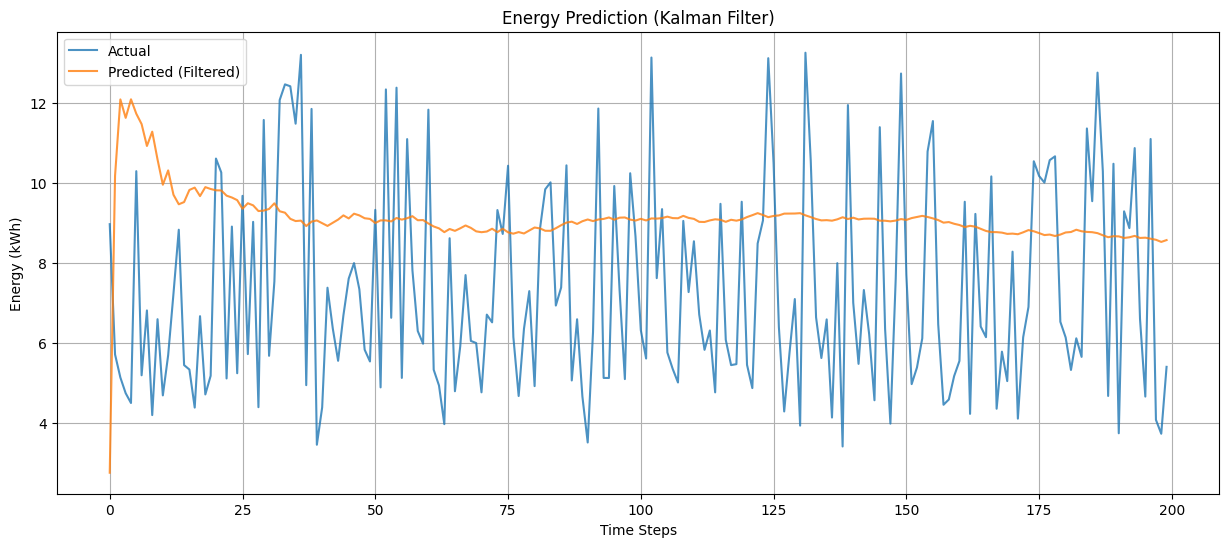

In [3]:
# Evaluate metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_filtered_rescaled))
mae = mean_absolute_error(y_test_actual, y_pred_filtered_rescaled)
r2 = r2_score(y_test_actual, y_pred_filtered_rescaled)
mape = np.mean(np.abs((y_test_actual - y_pred_filtered_rescaled) / y_test_actual)) * 100

print("\nModel Performance (with Kalman Filter):")
print(f"Root Mean Square Error (RMSE): {rmse:.3f}")
print(f"Mean Absolute Error (MAE): {mae:.3f} kWh")
print(f"R-squared Score: {r2:.3f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Plot predictions
def plot_predictions(y_test_actual, y_pred, num_points=200):
    plt.figure(figsize=(15, 6))
    plt.plot(y_test_actual[:num_points], label='Actual', alpha=0.8)
    plt.plot(y_pred[:num_points], label='Predicted (Filtered)', alpha=0.8)
    plt.title('Energy Prediction (Kalman Filter)')
    plt.xlabel('Time Steps')
    plt.ylabel('Energy (kWh)')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_predictions(y_test_actual, y_pred_filtered_rescaled)